In [141]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import stable_retro
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
import random
from collections import deque

#### Mario Environment and Rewards

In [142]:
# Button order: [B, Y, SELECT, START, UP, DOWN, LEFT, RIGHT, A, X, L, R]
ACTIONS = [
    [0,0,0,0,0,0,0,0,0,0,0,0],  # no-op
    [0,0,0,0,0,0,0,1,0,0,0,0],  # right
    [0,0,0,0,0,0,0,1,1,0,0,0],  # right + A (jump)
    [0,1,0,0,0,0,0,1,0,0,0,0],  # right + Y (run)
    [0,1,0,0,0,0,0,1,1,0,0,0],  # right + Y + A (run jump)
    [0,0,0,0,0,0,0,0,1,0,0,0],  # A (jump in place)
    [0,0,0,0,0,0,1,0,0,0,0,0],  # left
    [0,0,0,0,0,0,1,0,1,0,0,0],  # left + A (jump left)
    [0,1,0,0,0,0,1,0,0,0,0,0],  # left + Y (run left)
]

def compute_reward(prev_info, curr_info, done, curr_x, max_x):
    reward = 0.0

    prev_x = int(prev_info.get('screen', 0)) * 256 + int(prev_info.get('x', 0))
    delta_x = curr_x - prev_x

    # --- Progress ---
    curr_pos = curr_info.get('screen', 0) * 256 + curr_info.get('x', 0)
    prev_pos = prev_info.get('screen', 0) * 256 + prev_info.get('x', 0)

    delta_x = curr_pos - prev_pos
    if delta_x > 0:
        reward += delta_x * 0.05

    # --- Milestones ---
    if curr_info.get('midpoint_flag', 0) > prev_info.get('midpoint_flag', 0):
        reward += 5.0

    if curr_info.get('game_mode', 20) == 12 and prev_info.get('game_mode', 20) == 20:
        reward += 10.0

    # --- Powerups ---
    if curr_info.get('powerup_status', 0) > prev_info.get('powerup_status', 0):
        reward += 1.0

    reward -= 0.001

    return reward

In [143]:
class SMWEnv(gym.Wrapper):
    def __init__(self, env, frame_skip=4, max_episode_steps=4500):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=np.zeros(5, dtype=np.float32),
            high=np.ones(5, dtype=np.float32),
            dtype=np.float32
        )
        self.action_space = gym.spaces.Discrete(len(ACTIONS))
        self.frame_skip = frame_skip
        self.max_episode_steps = max_episode_steps
        self.prev_info = {}
        self.max_x = 0
        self._steps = 0
        self._lives = 4

    def reset(self, **kwargs):
        _, info = self.env.reset(**kwargs)
        while int(info.get('game_mode', 20)) in (18, 19):
            _, info = self.env.reset(**kwargs)
        self.prev_info = info
        self.max_x = int(info.get('screen', 0)) * 256 + int(info.get('x', 0))
        self._steps = 0
        self._lives = int(info.get('lives', 4))
        return self._get_obs(info), info

    def step(self, action_idx):
        buttons = ACTIONS[action_idx]
        total_reward = 0.0
        last_info = self.prev_info
        terminated, truncated = False, False

        for _ in range(self.frame_skip):
            _, _, terminated, truncated, last_info = self.env.step(buttons)

            curr_time = last_info.get('timer_h', 0) * 100 + last_info.get('timer_t', 0) * 10 + last_info.get('timer_o', 0)
            if curr_time == 0:
                terminated = True
                total_reward -= 3.0
            if last_info.get('game_mode', 20) == 11 and self.prev_info.get('game_mode', 20) == 20:
                terminated = True
                total_reward -= 3.0
            if last_info.get('game_mode', 20) == 12 and self.prev_info.get('game_mode', 20) == 20:
                terminated = True

            # print(f"game_mode={last_info.get('game_mode', 'N/A')}")

        self._steps += 1
        if self._steps >= self.max_episode_steps:
            truncated = True

        curr_x = int(last_info.get('screen', 0)) * 256 + int(last_info.get('x', 0))
        total_reward += compute_reward(self.prev_info, last_info, terminated or truncated, curr_x, self.max_x)
        self.max_x = max(self.max_x, curr_x)
        self.prev_info = last_info
        self._lives = int(last_info.get('lives', self._lives))
        return self._get_obs(last_info), total_reward, terminated, truncated, last_info

    def _get_obs(self, info):
        return np.array([
            info.get('screen', 0) / 255.0,
            info.get('x', 0) / 9999.0,
            info.get('powerup status', 0) / 3.0,
            float(info.get('riding yoshi', 0)),
            float(info.get('midpoint flag', 0)),
        ], dtype=np.float32)


#### Rainbow DQN Network

In [144]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))
        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))
        self._std_init = std_init
        self.reset_parameters()
        self.sample_noise()

    def reset_parameters(self):
        bound = self.in_features**-0.5
        self.weight_mu.data.uniform_(-bound, bound)
        self.weight_sigma.data.fill_(self._std_init * bound)
        self.bias_mu.data.uniform_(-bound, bound)
        self.bias_sigma.data.fill_(self._std_init * bound)

    def _f(self, x):
        return x.sign()*x.abs().sqrt()

    def sample_noise(self):
        p = self._f(torch.randn(self.in_features))
        q = self._f(torch.randn(self.out_features))
        self.weight_epsilon.copy_(q.outer(p))
        self.bias_epsilon.copy_(q)

    def forward(self, x):
        if self.training:
            w = self.weight_mu + self.weight_sigma*self.weight_epsilon
            b = self.bias_mu + self.bias_sigma*self.bias_epsilon
        else:
            w, b = self.weight_mu, self.bias_mu
        return F.linear(x, w, b)


class RainbowNet(nn.Module):
    """Dueling + Distributional network with NoisyLinear layers."""
    def __init__(self, obs_dim, action_dim, n_atoms, hidden=128):
        super().__init__()
        self.action_dim = action_dim
        self.n_atoms = n_atoms

        self.features = nn.Sequential(nn.Linear(obs_dim, hidden), nn.ReLU())

        # Value stream
        self.value_hidden = NoisyLinear(hidden, hidden)
        self.value_out = NoisyLinear(hidden, n_atoms)

        # Advantage stream
        self.adv_hidden = NoisyLinear(hidden, hidden)
        self.adv_out = NoisyLinear(hidden, action_dim * n_atoms)

    def forward(self, x):
        f = self.features(x)
        v = F.relu(self.value_hidden(f))
        v = self.value_out(v).view(-1, 1, self.n_atoms)
        a = F.relu(self.adv_hidden(f))
        a = self.adv_out(a).view(-1, self.action_dim, self.n_atoms)
        q = v + a - a.mean(dim=1, keepdim=True)      # dueling combination
        return F.softmax(q, dim=2)                    # probability distributions

    def sample_noise(self):
        for m in [self.value_hidden, self.value_out, self.adv_hidden, self.adv_out]:
            m.sample_noise()

#### Prioritized Replay Buffer

In [145]:
class SumTree:
    def __init__(self, capacity):
        self.capacity = capacity
        self.tree = np.zeros(2*capacity - 1)
        self.data = [None]*capacity
        self.write = 0
        self.n_entries = 0

    def _propagate(self, idx, change):
        parent = (idx - 1)//2
        self.tree[parent] += change
        if parent:
            self._propagate(parent, change)

    def _retrieve(self, idx, s):
        left = 2*idx + 1
        if left >= len(self.tree):
            return idx
        return self._retrieve(left, s) if s <= self.tree[left] else self._retrieve(left + 1, s - self.tree[left])

    def add(self, p, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, p)
        self.write = (self.write + 1) % self.capacity
        self.n_entries = min(self.n_entries + 1, self.capacity)

    def update(self, idx, p):
        self._propagate(idx, p - self.tree[idx])
        self.tree[idx] = p

    def get(self, s):
        idx = self._retrieve(0, min(s, self.tree[0]))
        return idx, self.tree[idx], self.data[idx - self.capacity + 1]

    @property
    def total(self):
        return self.tree[0]


class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta=0.4, beta_increment=0.001, eps=1e-6):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.beta = beta
        self.beta_increment = beta_increment
        self.eps = eps
        self.max_priority   = 1.0

    def add(self, transition):
        self.tree.add(self.max_priority**self.alpha, transition)

    def sample(self, batch_size):
        batch, idxs, priorities = [], [], []
        segment = self.tree.total/batch_size
        self.beta = min(1.0, self.beta + self.beta_increment)

        for i in range(batch_size):
            s = random.uniform(segment*i, segment*(i + 1))
            idx, p, data = self.tree.get(s)
            batch.append(data)
            idxs.append(idx)
            priorities.append(p)

        probs = np.array(priorities)/self.tree.total
        weights = (len(self)*probs)**-self.beta
        weights /= weights.max()
        return batch, idxs, torch.tensor(weights, dtype=torch.float32)

    def update_priorities(self, idxs, td_errors):
        for idx, err in zip(idxs, td_errors):
            p = (abs(err) + self.eps)**self.alpha
            self.tree.update(idx, p)
            self.max_priority = max(self.max_priority, p)

    def __len__(self):
        return self.tree.n_entries

#### Rainbow DQN Agent

In [146]:
class RainbowAgent:
    def __init__(self, obs_dim, action_dim, n_atoms=51, v_min=-20.0, v_max=300.0,
                 gamma=0.99, n_step=3, lr=1e-4, batch_size=32,
                 memory_size=50000, target_update=500, device='cpu'):
        self.device = torch.device(device)
        self.action_dim = action_dim
        self.n_atoms = n_atoms
        self.v_min = v_min
        self.v_max = v_max
        self.gamma = gamma
        self.n_step = n_step
        self.batch_size = batch_size
        self.target_update = target_update
        self.learn_step = 0

        self.support = torch.linspace(v_min, v_max, n_atoms).to(self.device)
        self.delta_z = (v_max - v_min)/(n_atoms - 1)

        self.online = RainbowNet(obs_dim, action_dim, n_atoms).to(self.device)
        self.target = RainbowNet(obs_dim, action_dim, n_atoms).to(self.device)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        self.optimizer = optim.Adam(self.online.parameters(), lr=lr)
        self.memory = PrioritizedReplayBuffer(memory_size)
        self.n_step_buf = deque(maxlen=n_step)

    def select_action(self, state):
        self.online.sample_noise()
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q = (self.online(s)*self.support).sum(dim=2)
            return q.argmax(dim=1).item()

    def store(self, state, action, reward, next_state, done):
        self.n_step_buf.append((state, action, reward, next_state, done))
        if len(self.n_step_buf) == self.n_step:
            self.memory.add(self._n_step_transition())

    def _n_step_transition(self):
        state, action = self.n_step_buf[0][:2]
        n_reward, n_next, n_done = 0.0, self.n_step_buf[-1][3], self.n_step_buf[-1][4]
        for i, (_, _, r, ns, d) in enumerate(self.n_step_buf):
            n_reward += (self.gamma**i)*r
            if d:
                n_next, n_done = ns, True
                break
        return (state, action, n_reward, n_next, n_done)

    def learn(self):
        if len(self.memory) < self.batch_size:
            return None

        batch, idxs, weights = self.memory.sample(self.batch_size)
        weights = weights.to(self.device)

        states, actions, rewards, next_states, dones = zip(*batch)
        states = torch.tensor(np.array(states), dtype=torch.float32, device=self.device)
        actions = torch.tensor(actions, dtype=torch.long,    device=self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=self.device)
        dones = torch.tensor(dones, dtype=torch.float32, device=self.device)

        B = self.batch_size

        with torch.no_grad():
            # Double DQN: online selects action, target evaluates it
            next_q = (self.online(next_states) * self.support).sum(dim=2)
            best_a = next_q.argmax(dim=1)
            next_dist = self.target(next_states)[range(B), best_a]

            # Categorical projection (C51)
            Tz = rewards.unsqueeze(1) + (1 - dones.unsqueeze(1))*(self.gamma**self.n_step)*self.support.unsqueeze(0)
            Tz = Tz.clamp(self.v_min, self.v_max)
            b = (Tz - self.v_min)/self.delta_z
            l = b.floor().long().clamp(0, self.n_atoms - 1)
            u = b.ceil().long().clamp(0, self.n_atoms - 1)

            m = torch.zeros(B, self.n_atoms, device=self.device)
            off = torch.arange(0, B*self.n_atoms, self.n_atoms, device=self.device).unsqueeze(1)
            m.view(-1).index_add_(0, (l + off).view(-1), (next_dist*(u.float() - b)).view(-1))
            m.view(-1).index_add_(0, (u + off).view(-1), (next_dist*(b - l.float())).view(-1))

        log_p = torch.log(self.online(states)[range(B), actions] + 1e-8)
        loss = -(m*log_p).sum(dim=1)
        w_loss = (loss*weights).mean()

        self.optimizer.zero_grad()
        w_loss.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 10.0)
        self.optimizer.step()

        self.memory.update_priorities(idxs, loss.detach().cpu().numpy())
        self.online.sample_noise()
        self.target.sample_noise()

        self.learn_step += 1
        if self.learn_step % self.target_update == 0:
            self.target.load_state_dict(self.online.state_dict())

        return w_loss.item()

#### Training

Episode    0 | Reward:     67.2 | Steps:   179 | Max X:  1132 | Loss: nan
Episode    1 | Reward:     69.1 | Steps:   196 | Max X:  1174 | Loss: nan
Episode    2 | Reward:     69.2 | Steps:   190 | Max X:  1172 | Loss: nan
Episode    3 | Reward:     95.0 | Steps:   186 | Max X:  1195 | Loss: nan
Episode    4 | Reward:     66.3 | Steps:   187 | Max X:  1095 | Loss: nan
Episode    5 | Reward:     68.2 | Steps:   182 | Max X:  1136 | Loss: nan
Episode    6 | Reward:     66.5 | Steps:   155 | Max X:  1126 | Loss: nan
Episode    7 | Reward:     71.0 | Steps:   176 | Max X:  1223 | Loss: nan
Episode    8 | Reward:     67.3 | Steps:   165 | Max X:  1145 | Loss: nan
Episode    9 | Reward:     68.9 | Steps:   210 | Max X:  1172 | Loss: nan
Episode   10 | Reward:     67.3 | Steps:   156 | Max X:  1152 | Loss: nan
Episode   11 | Reward:     68.9 | Steps:   203 | Max X:  1151 | Loss: 3.4383
Episode   12 | Reward:     65.3 | Steps:   226 | Max X:  1058 | Loss: 2.9862
Episode   13 | Reward:     68.5 

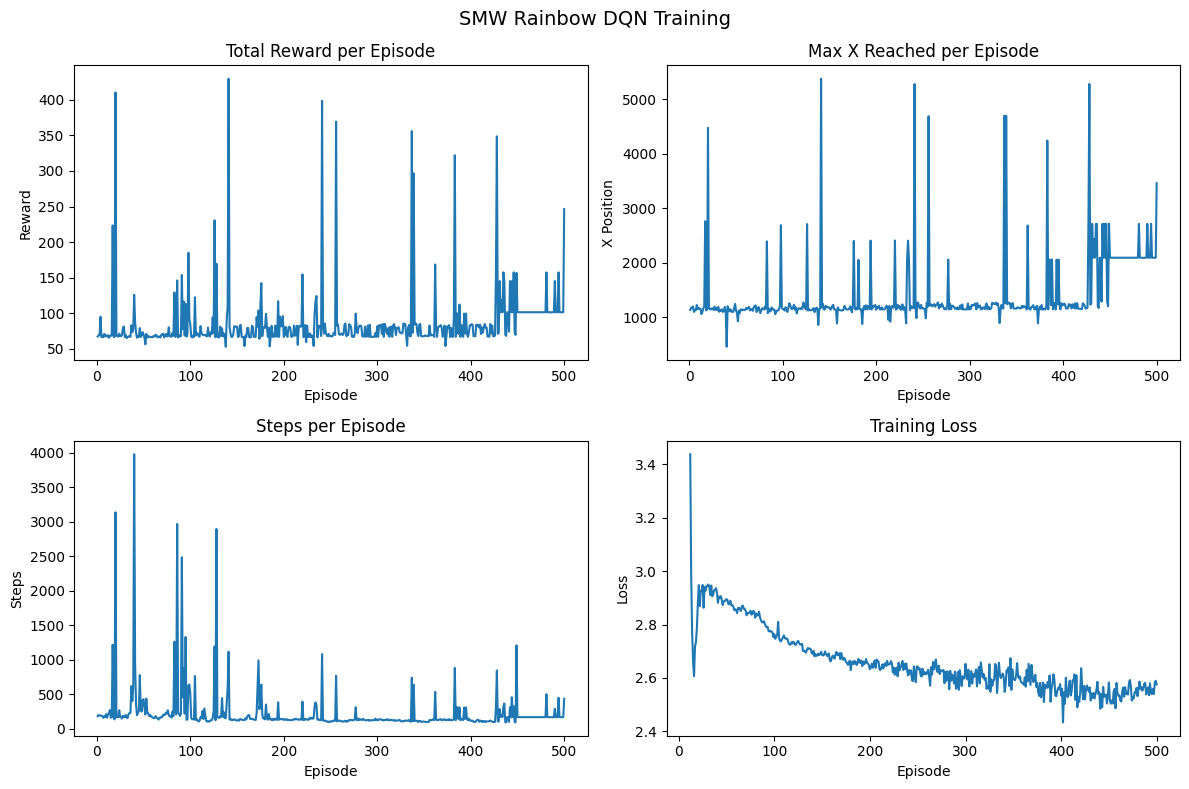

In [148]:
num_episodes = 500
warmup_steps = 2000
learn_every = 4

total_rewards, steps_per_ep, max_x_per_ep, ep_losses = [], [], [], []

# Close any existing environment from a previous run
try: env.close()
except: pass

base_env = stable_retro.make('SuperMarioWorld-Snes-v0', render_mode='none')
env = SMWEnv(base_env)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
agent = RainbowAgent(obs_dim=env.observation_space.shape[0], action_dim=len(ACTIONS), device=device)

total_steps = 0

for ep in range(num_episodes):
    state, _ = env.reset()
    ep_reward, ep_steps, losses = 0.0, 0, []

    while True:
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.store(state, action, reward, next_state, done)

        if total_steps >= warmup_steps and total_steps % learn_every == 0:
            loss = agent.learn()
            if loss is not None:
                losses.append(loss)

        state = next_state
        ep_reward += reward
        ep_steps += 1
        total_steps += 1

        if done:
            break

    total_rewards.append(ep_reward)
    steps_per_ep.append(ep_steps)
    max_x_per_ep.append(env.max_x)
    ep_losses.append(np.mean(losses) if losses else float('nan'))

    # if ep % 10 == 0:
    #     print(f'Episode {ep:4d} | Reward: {ep_reward:8.1f} | Steps: {ep_steps:5d} | Max X: {env.max_x:5d} | Loss: {ep_losses[-1]:.4f}')

    print(f'Episode {ep:4d} | Reward: {ep_reward:8.1f} | Steps: {ep_steps:5d} | Max X: {env.max_x:5d} | Loss: {ep_losses[-1]:.4f}')

env.close()

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SMW Rainbow DQN Training', fontsize=14)

eps = range(1, num_episodes + 1)

axes[0,0].plot(eps, total_rewards)
axes[0,0].set_title('Total Reward per Episode')
axes[0,0].set_xlabel('Episode')
axes[0,0].set_ylabel('Reward')

axes[0,1].plot(eps, max_x_per_ep)
axes[0,1].set_title('Max X Reached per Episode')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_ylabel('X Position')

axes[1,0].plot(eps, steps_per_ep)
axes[1,0].set_title('Steps per Episode')
axes[1,0].set_xlabel('Episode')
axes[1,0].set_ylabel('Steps')

axes[1,1].plot(eps, ep_losses)
axes[1,1].set_title('Training Loss')
axes[1,1].set_xlabel('Episode')
axes[1,1].set_ylabel('Loss')

plt.tight_layout()
plt.savefig('rainbow_results.png')
plt.show()